In [15]:
# Usage guide:

# This document is not kept on record. If the calcualtions are to be kept,
# copy the whole notebook and put it in "quick_calculations" or appropriate
# folders.

In [16]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

In [ ]:
# Temperature range 0 to 100 Celsius
T_C = np.linspace(0, 100, 1000)
T_K = T_C + 273.15

# --- Rubidium (Daniel A. Steck) ---
Rb_Tm_K = 312.45
Rb_Tm_C = Rb_Tm_K - 273.15

P_Rb_torr = np.zeros_like(T_K)
for i, T in enumerate(T_K):
    if T < Rb_Tm_K:
        P_Rb_torr[i] = 10**(2.881 + 4.857 - 4215.0 / T)
    else:
        P_Rb_torr[i] = 10**(2.881 + 4.312 - 4040.0 / T)

# Vapor pressure at the exact melting point
P_Rb_Tm_torr = 10**(2.881 + 4.857 - 4215.0 / Rb_Tm_K)

# --- Potassium (Tobias Tiecke) ---
K_Tm_K = 336.8
K_Tm_C = K_Tm_K - 273.15

P_K_mbar = np.zeros_like(T_K)
for i, T in enumerate(T_K):
    if T < K_Tm_K:
        P_K_mbar[i] = 10**(7.9667 - 4646.0 / T)
    else:
        P_K_mbar[i] = 10**(7.4077 - 4453.0 / T)

# Convert from mbar to Torr
P_K_torr = P_K_mbar * 0.750062

# Vapor pressure at the exact melting point
P_K_Tm_torr = (10**(7.9667 - 4646.0 / K_Tm_K)) * 0.750062

# --- 40K Vapor Pressure ---
P_40K_torr = P_K_torr * 0.0315

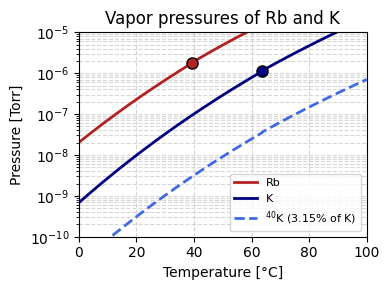

In [ ]:
# --- Object-Oriented Plotting ---
fig, ax = plt.subplots(figsize=(4, 3))

# Main vapor pressure curves
ax.plot(T_C, P_Rb_torr, label='Rb', color='firebrick', linewidth=2)
ax.plot(T_C, P_K_torr, label='K', color='navy', linewidth=2)
ax.plot(T_C, P_40K_torr, label=r'$^{40}$K (3.15% of K)', color='royalblue', linestyle='--', linewidth=2)

# Point markers for melting transitions
ax.plot(Rb_Tm_C, P_Rb_Tm_torr, marker='o', markersize=8, color='firebrick', 
        markeredgecolor='black', linestyle='None')#, label=f'Rb Melting Point (~{Rb_Tm_C:.1f} °C)')
ax.plot(K_Tm_C, P_K_Tm_torr, marker='o', markersize=8, color='navy', 
        markeredgecolor='black', linestyle='None')#, label=f'K Melting Point (~{K_Tm_C:.1f} °C)')

# Setting axes properties
ax.set_yscale('log')
ax.set_ylim([1e-10, 1e-5])
ax.set_xlim([0, 100])

ax.set_xlabel('Temperature [°C]', fontsize=10)
ax.set_ylabel('Pressure [Torr]', fontsize=10)
ax.set_title('Vapor pressures of Rb and K', fontsize=12)

ax.legend(fontsize=8)
ax.grid(True, which="both", ls="--", alpha=0.5)
fig.tight_layout()

# Save image
thesis_fig_path = Path(r'C:\Users\ken92\Documents\Studies\E5\Theses\figures\apparatus')
fig_path = Path(thesis_fig_path, f"vapor_pressure.pdf")
# fig.savefig(fig_path, dpi=300)